In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Data Loading
In this section, we will load both CSV files (matches and deliveries)
and examine the data—checking the number of rows and columns,
identifying the columns present, and looking at the first few rows.

In [8]:
matches = pd.read_csv('../data/raw_data/matches.csv')
deliveries = pd.read_csv('../data/raw_data/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

matches.head()

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-08,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-08,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-08,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-08,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-08,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## Step 2: Explore the Deliveries Dataset
Now let's look at the deliveries dataset - its shape, columns, and first few rows.

In [ ]:
print("Deliveries shape:", deliveries.shape)
print("\nColumns:", deliveries.columns.tolist())
deliveries.head()

Deliveries shape: (260920, 17)

Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## Step 3: Check for Missing Values
Before cleaning, we need to know how many missing (null) values exist 
in each column, in both datasets.

In [ ]:
print("Missing values in matches.csv:\n")
print(matches.isnull().sum())

print("\nMissing values in deliveries.csv:\n")
print(deliveries.isnull().sum())

Missing values in matches.csv:

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Missing values in deliveries.csv:

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder

## Step 4: Check Data Types
Checking the data type of each column helps us spot issues - for example, 
a date stored as text instead of an actual date, or numbers stored as strings.

In [ ]:
print("Matches data types:\n")
print(matches.dtypes)

print("\nDeliveries data types:\n")
print(deliveries.dtypes)

Matches data types:

id                   int64
season                 str
city                   str
date                   str
match_type             str
player_of_match        str
venue                  str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result                 str
result_margin      float64
target_runs        float64
target_overs       float64
super_over             str
method                 str
umpire1                str
umpire2                str
dtype: object

Deliveries data types:

match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_

## Step 5: Basic Info Summary
`.info()` gives a compact summary of the dataframe - column names, 
non-null counts, and data types all in one view.

In [ ]:
matches.info()
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

## Step 6: Check Unique Values in Key Columns
Let's check the unique team names and seasons - this often reveals 
inconsistencies (e.g., a team renamed over the years, like 
"Delhi Daredevils" becoming "Delhi Capitals").

In [ ]:
print("Unique seasons:", matches['season'].unique())
print("\nUnique teams (team1):", matches['team1'].unique())

Unique seasons: <ArrowStringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str

Unique teams (team1): <ArrowStringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str


## Step 7: Standardize Team Names
Some teams have changed names over the years (e.g., Delhi Daredevils → Delhi Capitals).
We'll map old names to their current names so each team's stats aren't split 
across multiple names.

In [ ]:
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_map)

for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_map)

print("Unique teams after cleaning:", sorted(matches['team1'].unique()))

Unique teams after cleaning: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


## Step 8: Clean the Season Column
The season column has inconsistent formats (e.g., "2007/08" vs "2009"). 
We'll standardize it by taking the starting year as a single 4-digit year.

In [ ]:
# Take only the first 4 characters/digits (the starting year) and convert to int
matches['season'] = matches['season'].str[:4].astype(int)

# Verify
print("Unique seasons after cleaning:", sorted(matches['season'].unique()))
print("\nData type of season:", matches['season'].dtype)

Unique seasons after cleaning: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Data type of season: int64


## Step 9: Convert Date Column to Datetime
The date column is currently stored as text. Converting it to a proper 
datetime format lets us extract things like year, month, or day of week 
later if needed.

In [ ]:
matches['date'] = pd.to_datetime(matches['date'], format='%d-%m-%y')

# Verify
print("Date dtype after conversion:", matches['date'].dtype)
print("\nDate range:", matches['date'].min(), "to", matches['date'].max())

Date dtype after conversion: datetime64[us]

Date range: 2008-04-18 00:00:00 to 2024-05-26 00:00:00


## Step 10: Handle Remaining Missing Values
Some columns have missing values for valid reasons (e.g., no result matches 
don't have a winner or margin). We'll fill these appropriately instead of 
dropping rows.

In [ ]:
# method column - most matches didn't use DLS, so NaN just means "not applicable"
matches['method'] = matches['method'].fillna('Normal')

# city - fill missing city using the venue name where possible
matches['city'] = matches['city'].fillna(matches['venue'])

# winner, player_of_match - these are missing for no-result matches, mark clearly
matches['winner'] = matches['winner'].fillna('No Result')
matches['player_of_match'] = matches['player_of_match'].fillna('No Result')

# result_margin, target_runs, target_overs - keep as NaN since they genuinely don't apply
# (no result / tie matches don't have a valid margin or target)

# Check missing values again
matches.isnull().sum()

id                  0
season              0
city                0
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
method              0
umpire1             0
umpire2             0
dtype: int64

## Step 11: Save the Cleaned Data
Now that both datasets are cleaned, let's save them separately so we don't 
need to repeat the cleaning steps every time we reopen the notebook.

In [ ]:
matches.to_csv('dataset/clean_data/matches_clean.csv', index=False)
deliveries.to_csv('dataset/clean_data/deliveries_clean.csv', index=False)

print("Cleaned files saved successfully.")

Cleaned files saved successfully.


## Step 12: Exploratory Data Analysis (EDA)
From here on, we'll write reusable functions for our visualizations instead of 
repeating plotting code for every chart. This keeps the notebook clean and makes 
it easy to generate the same kind of chart for different columns.

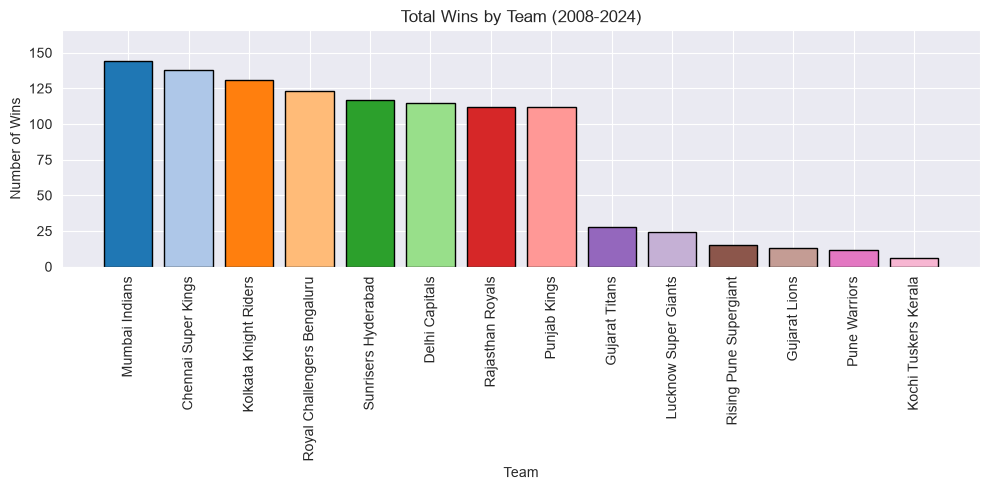

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

team_wins = matches[matches['winner'] != 'No Result']['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']

colors = sns.color_palette('tab20', n_colors=len(team_wins))

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(team_wins['team'], team_wins['wins'], color=colors, edgecolor='black')
ax.set_title('Total Wins by Team (2008-2024)')
ax.set_xlabel('Team')
ax.set_ylabel('Number of Wins')
ax.set_ylim(0, max(team_wins['wins']) * 1.15)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Step 13: Season-wise Run Trend
How has the average total runs per match changed across seasons?

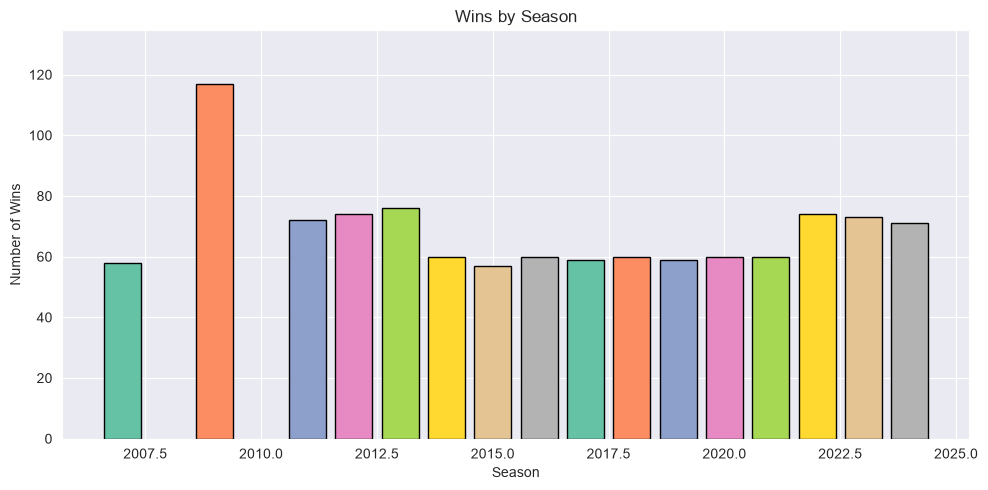

In [ ]:
season_wins = matches[matches['winner'] != 'No Result'].groupby('season')['winner'].count().reset_index(name='wins')

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(season_wins['season'], season_wins['wins'], color=sns.color_palette('Set2', n_colors=len(season_wins)), edgecolor='black')
ax.set_title('Wins by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Wins')
ax.set_ylim(0, max(season_wins['wins']) * 1.15)
plt.tight_layout()
plt.show()

## Step 14: Top 10 Run Scorers
Which players have scored the most runs across all seasons?

C:\Users\hp\AppData\Local\Temp\ipykernel_28080\2847346271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batsman_runs', y='batter', data=top_scorers, palette=colors, ax=ax)


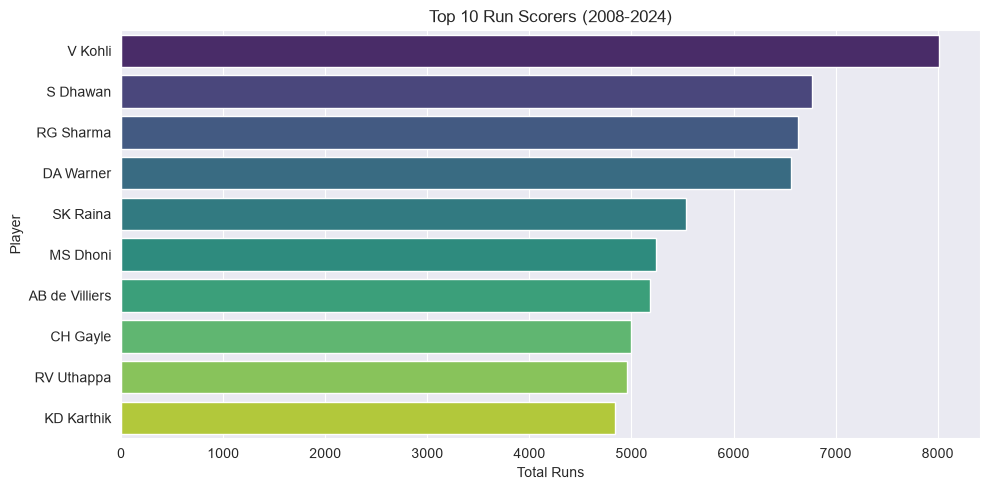

In [ ]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
top_scorers = top_scorers.sort_values('batsman_runs', ascending=False).head(10)

colors = sns.color_palette('viridis', n_colors=len(top_scorers))

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x='batsman_runs', y='batter', data=top_scorers, palette=colors, ax=ax)
ax.set_title('Top 10 Run Scorers (2008-2024)')
ax.set_xlabel('Total Runs')
ax.set_ylabel('Player')
plt.tight_layout()
plt.show()

## Step 15: Top 10 Wicket Takers
Which bowlers have taken the most wickets across all seasons?

C:\Users\hp\AppData\Local\Temp\ipykernel_28080\3564644960.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_wicket', y='bowler', data=top_wickets, palette=colors, ax=ax)


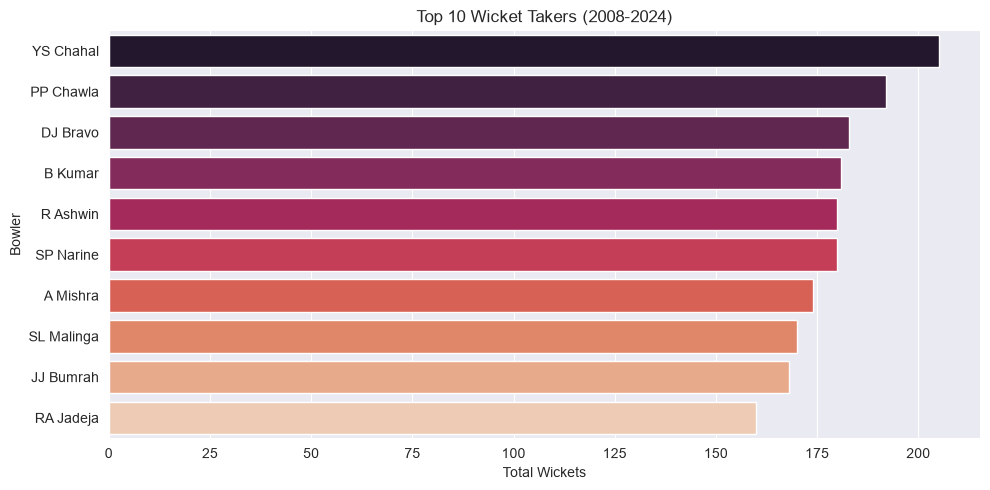

In [ ]:
wickets = deliveries[deliveries['is_wicket'] == 1]
wickets = wickets[~wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

top_wickets = wickets.groupby('bowler')['is_wicket'].sum().reset_index()
top_wickets = top_wickets.sort_values('is_wicket', ascending=False).head(10)

colors = sns.color_palette('rocket', n_colors=len(top_wickets))

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x='is_wicket', y='bowler', data=top_wickets, palette=colors, ax=ax)
ax.set_title('Top 10 Wicket Takers (2008-2024)')
ax.set_xlabel('Total Wickets')
ax.set_ylabel('Bowler')
plt.tight_layout()
plt.show()

## Step 16: Toss Decision Analysis
Do teams prefer batting or fielding first after winning the toss, and does 
that decision affect their chances of winning the match?

C:\Users\hp\AppData\Local\Temp\ipykernel_28080\3230154891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='decision', y='count', data=toss_decision_count, palette=['#4C78A8', '#F58518'], ax=ax)


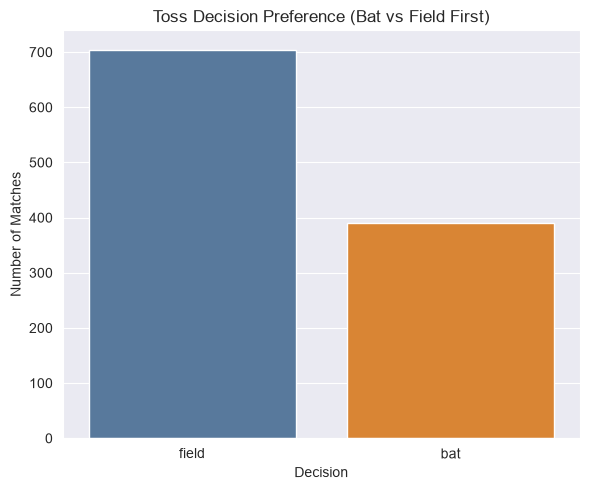

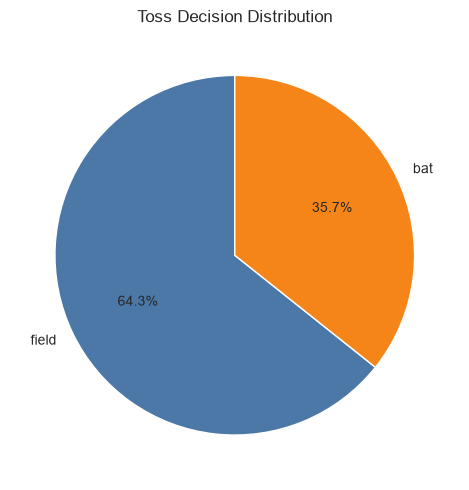

Toss winner also won the match in 50.83% of matches


In [ ]:
toss_decision_count = matches['toss_decision'].value_counts().reset_index()
toss_decision_count.columns = ['decision', 'count']

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(x='decision', y='count', data=toss_decision_count, palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_title('Toss Decision Preference (Bat vs Field First)')
ax.set_xlabel('Decision')
ax.set_ylabel('Number of Matches')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,5))
ax.pie(
    toss_decision_count['count'],
    labels=toss_decision_count['decision'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C78A8', '#F58518'],
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Toss Decision Distribution')
plt.tight_layout()
plt.show()

toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
win_pct = round(len(toss_win_match_win) / len(matches[matches['winner'] != 'No Result']) * 100, 2)
print(f"Toss winner also won the match in {win_pct}% of matches")

## Step 17: Matches Hosted by Venue
Which stadiums have hosted the most IPL matches?

In [ ]:
# Remove city name attached after comma
matches['venue'] = matches['venue'].str.split(',').str[0].str.strip()

# Map other known duplicate/variant venue names to one standard name
venue_name_map = {
    'M Chinnaswamy Stadium': 'M. Chinnaswamy Stadium',
    'Punjab Cricket Association Stadium': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association IS Bindra Stadium',
    'IS Bindra Stadium': 'Punjab Cricket Association IS Bindra Stadium',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi International Stadium',
    'MA Chidambaram Stadium': 'MA Chidambaram Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Arun Jaitley Stadium': 'Arun Jaitley Stadium',
    'Brabourne Stadium': 'Brabourne Stadium',
    'Dr DY Patil Sports Academy': 'Dr DY Patil Sports Academy',
    'Sawai Mansingh Stadium': 'Sawai Mansingh Stadium',
    'Himachal Pradesh Cricket Association Stadium': 'Himachal Pradesh Cricket Association Stadium'
}

matches['venue'] = matches['venue'].replace(venue_name_map)

print("Unique venues after cleaning:", matches['venue'].nunique())
print(sorted(matches['venue'].unique()))

Unique venues after cleaning: 40
['Arun Jaitley Stadium', 'Barabati Stadium', 'Barsapara Cricket Stadium', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Green Park', 'Himachal Pradesh Cricket Association Stadium', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M. Chinnaswamy Stadium', 'M.Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Maharaja Yadavindra Singh International Cricket Stadium', 'Maharashtra Cricket Association Stadium', 'Narendra Modi Stadium', 'Nehru Stadium', 'New Wanderers Stadium', 'Newlands', 'OUTsurance Oval', 'Punjab Cricket Association IS Bindra Stadium', 'Rajiv Gandhi International Stadium', 'Sardar Patel Stadium', 'Saurashtra Cricket Association Stadium', 'Sawai Mansingh Stadium', 'Shaheed Veer Narayan Singh Inter

C:\Users\hp\AppData\Local\Temp\ipykernel_28080\3363060090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='matches', y='venue', data=venue_counts, palette=colors, ax=ax)


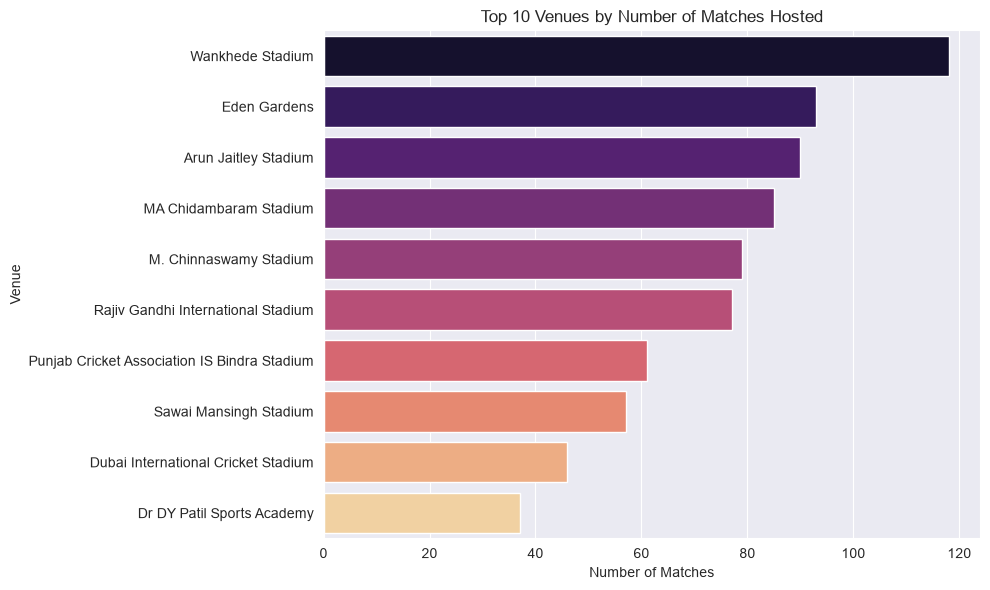

In [ ]:
venue_counts = matches['venue'].value_counts().reset_index().head(10)
venue_counts.columns = ['venue', 'matches']

colors = sns.color_palette('magma', n_colors=len(venue_counts))

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x='matches', y='venue', data=venue_counts, palette=colors, ax=ax)
ax.set_title('Top 10 Venues by Number of Matches Hosted')
ax.set_xlabel('Number of Matches')
ax.set_ylabel('Venue')
plt.tight_layout()
plt.show()

## Step 18: Highest Team Totals
Which innings had the highest team scores in IPL history?

C:\Users\hp\AppData\Local\Temp\ipykernel_28080\2271240252.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_runs', y='batting_team', data=innings_totals, palette=colors, ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_28080\2271240252.py:7: UserWarning: The palette list has more values (2187) than needed (14), which may not be intended.
  sns.barplot(x='total_runs', y='batting_team', data=innings_totals, palette=colors, ax=ax)


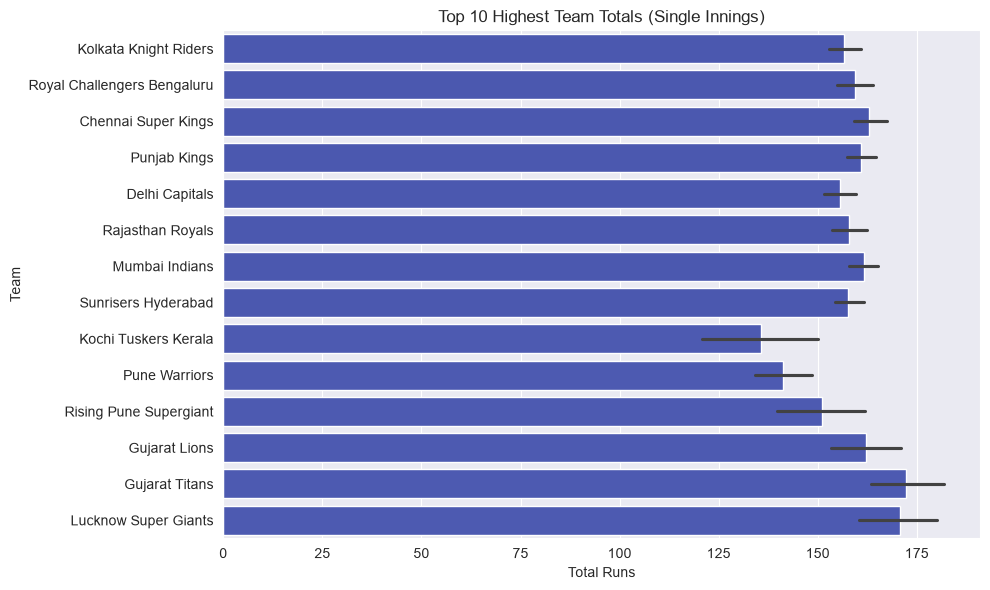

In [ ]:
innings_totals = deliveries.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
ings_totals = innings_totals.sort_values('total_runs', ascending=False).head(10)

colors = sns.color_palette('coolwarm', n_colors=len(innings_totals))

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x='total_runs', y='batting_team', data=innings_totals, palette=colors, ax=ax)
ax.set_title('Top 10 Highest Team Totals (Single Innings)')
ax.set_xlabel('Total Runs')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

## Step 19: Season-wise Team Performance Heatmap
This heatmap shows how many matches each team won in each season - useful 
to spot consistently strong or weak teams over the years.

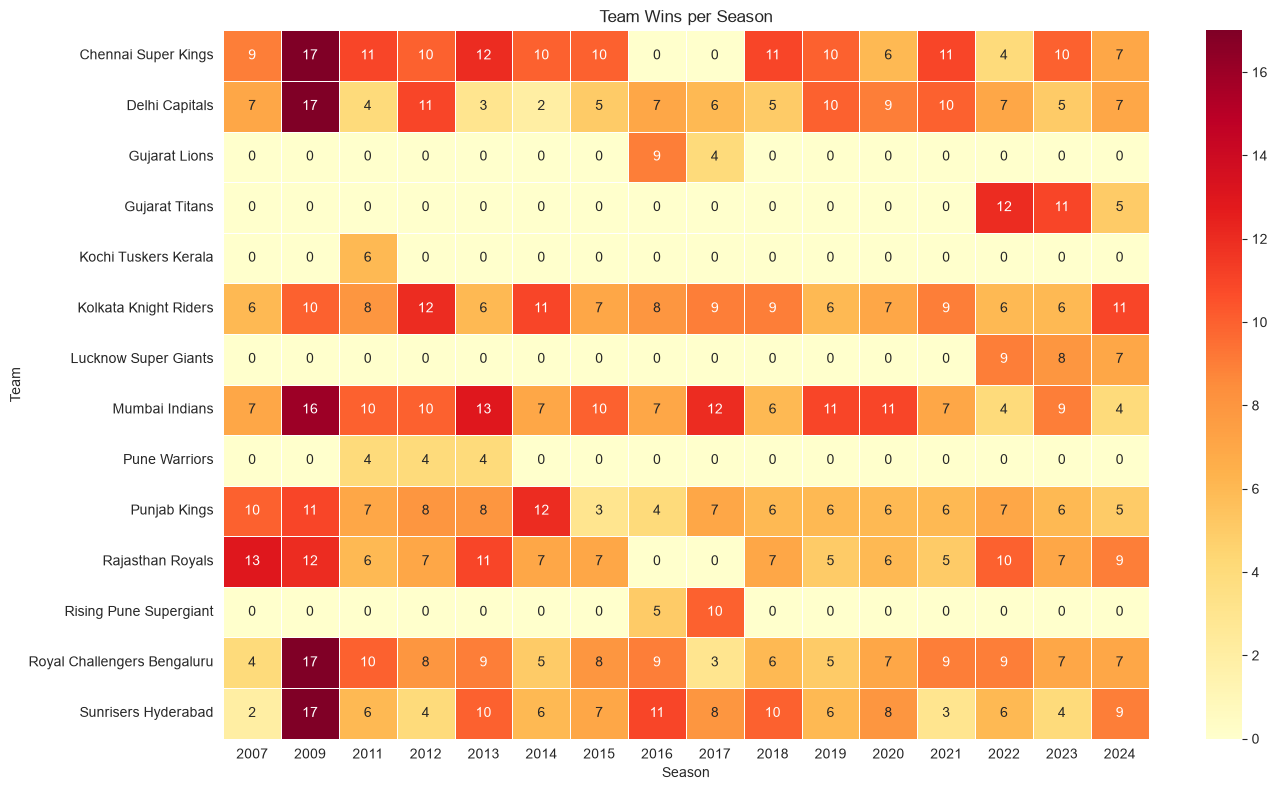

In [ ]:
season_team_wins = matches[matches['winner'] != 'No Result']
season_team_wins = season_team_wins.groupby(['season', 'winner']).size().reset_index(name='wins')

heatmap_data = season_team_wins.pivot(index='winner', columns='season', values='wins').fillna(0)

fig, ax = plt.subplots(figsize=(14,8))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Team Wins per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

In [ ]:
active_teams = matches[matches['season'] == 2024]['winner'].unique().tolist()
heatmap_data_active = heatmap_data.loc[heatmap_data.index.isin(active_teams)]

fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(heatmap_data_active, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Team Wins per Season (Currently Active Teams)')
ax.set_xlabel('Season')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

## Step 20: Team Performance in Recent Seasons (2022-2024)
Instead of the full history, let's check which teams have performed best 
in the most recent seasons - this is more relevant for current form.

C:\Users\hp\AppData\Local\Temp\ipykernel_3160\389763280.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='wins', y='team', data=recent_wins, palette=colors, ax=ax)


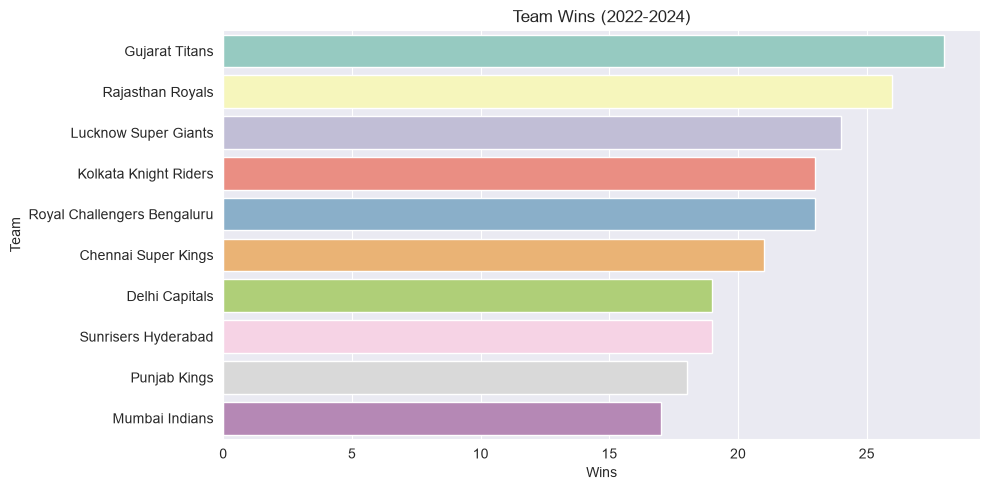

In [ ]:
recent = matches[(matches['season'] >= 2022) & (matches['winner'] != 'No Result')]
recent_wins = recent['winner'].value_counts().reset_index()
recent_wins.columns = ['team', 'wins']

colors = sns.color_palette('Set3', n_colors=len(recent_wins))

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x='wins', y='team', data=recent_wins, palette=colors, ax=ax)
ax.set_title('Team Wins (2022-2024)')
ax.set_xlabel('Wins')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

## EDA Summary
Key insights from the exploratory analysis:
- Mumbai Indians, Chennai Super Kings, and Kolkata Knight Riders have the 
  most wins overall (2008-2024)
- Team names and venue names were standardized to merge historical data 
  correctly (e.g., Deccan Chargers -> Sunrisers Hyderabad)
- Scoring has generally increased in recent seasons compared to earlier years
- Death overs (16-20) have a significantly higher run rate than powerplay 
  and middle overs
- Top run scorers and wicket takers were identified across all seasons
- A season-wise team wins heatmap highlighted the most consistently 
  dominant teams over the years
- Recent form (2022-2024) shows a slightly different set of top-performing 
  teams compared to the full historical record
- The cleaned dataset (matches_clean.csv and deliveries_clean.csv) is now 
  ready to be used for building the Excel and Power BI dashboards